# Working with mobile robots

This notebook introduces the RobotBlockSet workflow for robots mounted on mobile platforms. It shows how to create, configure, simulate, and control combined mobile-manipulator systems through a unified interface.


## What this notebook covers

The examples below demonstrate the main steps for working with a robot arm attached to a mobile base: initialization, state capture, platform and arm coordination, reachability-aware base motion, and analysis of robot/platform behavior during execution.

Use this notebook as a practical reference for understanding how RobotBlockSet represents mobile manipulators and how to adapt the workflow to your own robot-platform setup.


# Imports


In [2]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import time
from datetime import datetime

from robotblockset.tools import get_rbs_path
from robotblockset.platform_utils import check_panda_reach

from robotblockset.mujoco.robots_pymujoco import mujoco_scene, panda
from robotblockset.mujoco.platforms_pymujoco import tiagobase

np.set_printoptions(formatter={"float": "{: 0.4f}".format})

## Motion capture

Mobile manipulators combine a robot arm and a mobile base, so it is useful to capture both subsystems during coordinated motion. As in `tutorial_robots.ipynb` and `tutorial_platforms.ipynb`, we define callbacks that store actual and commanded states during updates.

The first callback is attached to the robot and reads the platform through `r.Platform`. The second callback is attached to the platform and reads the robot through `p.Robot`. Either direction works after the two objects are linked with `SetBasePlatform`.


In [3]:
ir = 0
def CaptureP_R(r):
    global ir, trun, tt, qt, rqt, qdt, rqdt, xt, vt, rxt, rvt, Ft, mt, xtw, vtw, rxtw, rvtw, pxt, ptht, pvt, prxt, prvt, pmt, puxt, rTbt
    p = r.Platform
    if ir == 0:
        tt = np.array(r.t)
        qt = r._actual.q
        qdt = r._actual.qdot
        rqt = r._command.q
        rqdt = r._command.qdot
        xt = r._actual.x
        vt = r._actual.v
        rxt = r._command.x
        rvt = r._command.v
        Ft = r._actual.FT
        mt = r._command.mode
        xtw = r.x
        vtw = r.GetVel(task_space="World", state="Actual")
        rxtw = r._command.rx
        rvtw = r.GetVel(task_space="World", state="Commanded")
        pxt = p._actual.x
        ptht = p.theta
        pvt = p._actual.v
        prxt = p._command.x
        prvt = p._command.v
        puxt = p._command.ux
        pmt = p._command.mode
        rTbt = r.GetBasePose(out="x")
    else:
        tt = np.vstack((tt, r.t))
        qt = np.vstack((qt, r._actual.q))
        qdt = np.vstack((qdt, r._actual.qdot))
        rqt = np.vstack((rqt, r._command.q))
        rqdt = np.vstack((rqdt, r._command.qdot))
        xt = np.vstack((xt, r._actual.x))
        vt = np.vstack((vt, r._actual.v))
        rxt = np.vstack((rxt, r._command.x))
        rvt = np.vstack((rvt, r._command.v))
        Ft = np.vstack((Ft, r._actual.FT))
        mt = np.vstack((mt, r._command.mode))
        xtw = np.vstack((xtw, r.x))
        vtw = np.vstack((vtw, r.GetVel(task_space="World", state="Actual")))
        rxtw = np.vstack((rxtw, r._command.rx))
        rvtw = np.vstack((rvtw, r.GetVel(task_space="World", state="Commanded")))
        pxt = np.vstack((pxt, p._actual.x))
        ptht = np.vstack((ptht, p.theta))
        pvt = np.vstack((pvt, p._actual.v))
        prxt = np.vstack((prxt, p._command.x))
        prvt = np.vstack((prvt, p._command.v))
        puxt = np.vstack((puxt, p._command.ux))
        pmt = np.vstack((pmt, p._command.mode))
        rTbt = np.vstack((rTbt, r.GetBasePose(out="x")))

    ir += 1

In [4]:
# Callback for Update
ip = 0
def CaptureR_P(p):
    global ip, trun, tt, qt, rqt, qdt, rqdt, xt, vt, rxt, rvt, Ft, mt, xtw, vtw, rxtw, rvtw, pxt, ptht, pvt, prxt, prvt, pmt, puxt, rTbt
    r = p.Robot
    if ip == 0:
        tt = np.array(r.t)
        qt = r._actual.q
        qdt = r._actual.qdot
        rqt = r._command.q
        rqdt = r._command.qdot
        xt = r._actual.x
        vt = r._actual.v
        rxt = r._command.x
        rvt = r._command.v
        Ft = r._actual.FT
        mt = r._command.mode
        xtw = r.x
        vtw = r.GetVel(task_space="World", state="Actual")
        rxtw = r._command.rx
        rvtw = r.GetVel(task_space="World", state="Commanded")
        pxt = p._actual.x
        ptht = p.theta
        pvt = p._actual.v
        prxt = p._command.x
        prvt = p._command.v
        puxt = p._command.ux
        pmt = p._command.mode
        rTbt = r.GetBasePose(out="x")
    else:
        tt = np.vstack((tt, r.t))
        qt = np.vstack((qt, r._actual.q))
        qdt = np.vstack((qdt, r._actual.qdot))
        rqt = np.vstack((rqt, r._command.q))
        rqdt = np.vstack((rqdt, r._command.qdot))
        xt = np.vstack((xt, r._actual.x))
        vt = np.vstack((vt, r._actual.v))
        rxt = np.vstack((rxt, r._command.x))
        rvt = np.vstack((rvt, r._command.v))
        Ft = np.vstack((Ft, r._actual.FT))
        mt = np.vstack((mt, r._command.mode))
        xtw = np.vstack((xtw, r.x))
        vtw = np.vstack((vtw, r.GetVel(task_space="World", state="Actual")))
        rxtw = np.vstack((rxtw, r._command.rx))
        rvtw = np.vstack((rvtw, r.GetVel(task_space="World", state="Commanded")))
        pxt = np.vstack((pxt, p._actual.x))
        ptht = np.vstack((ptht, p.theta))
        pvt = np.vstack((pvt, p._actual.v))
        prxt = np.vstack((prxt, p._command.x))
        prvt = np.vstack((prvt, p._command.v))
        puxt = np.vstack((puxt, p._command.ux))
        pmt = np.vstack((pmt, p._command.mode))
        rTbt = np.vstack((rTbt, r.GetBasePose(out="x")))

    ip += 1

# Mobile manipulator objects

A mobile manipulator in RobotBlockSet is modeled as a robot mounted on a mobile platform. The robot keeps its full joint-space and task-space interface from `robots.py`, while the base keeps its planar motion interface from `platforms.py`.

The key point is that, after attachment, the robot base pose is no longer fixed in the world. Instead, it is updated from the platform state, so robot task-space quantities such as `r.x` are expressed in the current world configuration of the full mobile-manipulator system.


# Creating a mobile manipulator object

The backend depends on the target system. In this tutorial, we use a MuJoCo scene that already contains a Tiago base, a Panda arm, and a box to grasp.

After creating the robot and platform objects, connect them with `r.SetBasePlatform(b)`. This is the mobile-manipulator equivalent of defining the robot base location in `tutorial_robots.ipynb` and the attached robot in `tutorial_platforms.ipynb`.


In [5]:
MODEL_PATH = get_rbs_path() + "/mujoco/mjcf_models/tiagobase_panda_box_scene.xml"
scene = mujoco_scene(MODEL_PATH, show_camera=None, synchronized=True, verbose=1)

r = panda(scene=scene) 
r._verbose = 2
b = tiagobase(scene=scene)
b._verbose = 2
r.SetBasePlatform(b)

[RBS_INFO] [04:31:14.592] [panda_PyMuJoCo]: Robot connected to MuJoCo
[RBS_INFO] [04:31:15.444] [tiagobase_PyMuJoCo]: Platform connected to MuJoCo


## Initialization and default parameters

Before running coordinated motion, set the initial joint configuration, synchronize the robot and platform sampling times, and adjust several default controller parameters.

The default `DampedPseudoInverseFactor` is increased to reduce oscillations when the robot moves near a singular configuration.

The capture callbacks are then registered on both subsystems so the later motion can be analyzed.


In [6]:
r.SetTsamp(0.01)
b.SetTsamp(0.01)
r._default.DampedPseudoInverseFactor = 0.1
r.SetCaptureCallback(CaptureP_R)
b.SetCaptureCallback(CaptureR_P)

## Preparing the mobile manipulator

A typical workflow is to first place the platform, then move the arm into a convenient joint configuration, and finally manipulate the object.

The next cells move the base to a known planar pose with `CMoveToLocation`, move the arm with `JMove`, place the box with `SetMocapPose`, move the tool to the box pose with `CMove`, and activate the MuJoCo equality constraint that represents the grasp.


In [7]:
b.CMoveToLocation([0, 0], rtheta=0, asynchronous=True)

[RBS_DEBUG] [04:31:15.871] [tiagobase_PyMuJoCo]: ASYNC CMoveToLocation


<Thread(Thread-6 (_CMoveToLocation), started daemon 33888)>

In [8]:
q_init = [0, -0.3, 0, -2.3,  0,  2.,  0.7776]
r.JMove(q_init, 2)

[RBS_DEBUG] [04:31:15.885] [panda_PyMuJoCo]: JMove started to: [ 0.0000 -0.3000  0.0000 -2.3000  0.0000  2.0000  0.7776] in 2.0s
[RBS_DEBUG] [04:31:15.918] [tiagobase_PyMuJoCo]: CMoveToLocation -> CMoveToOri
[RBS_DEBUG] [04:31:15.918] [tiagobase_PyMuJoCo]: CMoveToOri started: theta=0.000
[RBS_DEBUG] [04:31:15.954] [tiagobase_PyMuJoCo]: CMoveToOri finished
[RBS_DEBUG] [04:31:15.955] [tiagobase_PyMuJoCo]: CMoveToLocation finished
[RBS_DEBUG] [04:31:24.643] [panda_PyMuJoCo]: JMove finished


0

# Robot used to position the platform


In this example, the robot holds its current end-effector pose with a long `CMove`, while the platform executes `CMoveToLocation` in the object frame.

The robot fixes its end-effector location by grasping the object. In this setup, the robot can also be used as a precise sensor for the platform: the platform location can be inferred in the object frame from the constrained end-effector pose.

In simulation, place the object at the desired location first.


In [9]:
r.SetMocapPose("Box",[0.5, 0.0, 0.6])

Instead of simulating a physical grasp in MuJoCo, connect the end-effector to the object with an equality constraint.


In [10]:
r.CMove(r.GetObjectPose("site", "Box"))
r.SetEquality("Grasp_box",True)

[RBS_DEBUG] [04:31:24.668] [panda_PyMuJoCo]: CMove started: [ 0.5000  0.0000  0.6000  0.0000 -1.0000 -0.0000 -0.0000] with velocity 25.0%
[RBS_DEBUG] [04:31:28.788] [panda_PyMuJoCo]: CMove finished


After the grasp is established, `r.EEFixed = True` tells the mobile-manipulator model that the end-effector is constrained to an external object. This matters during subsequent base motion because the arm controller must respect that the tool pose is no longer free.


In [11]:
r.EEFixed = True

For combined motion, first align commanded and actual states with `ResetCurrentTarget` on both the platform and the robot. This avoids discontinuities when the next asynchronous commands start.

The platform command uses `robot_as_a_sensor=True` and `reach_check_fn=check_Panda_reach`, so the base controller continuously checks whether the arm can still reach the task while the base is moving.

Capture is enabled before the motion so both planar base states and robot world-frame task states can be plotted afterward.


In [12]:
b.ResetCurrentTarget()
r.ResetCurrentTarget()
b.ResetTime()
ip = 0
r.ResetTime()
ir = 0

x0 = r.x_ref
b.StartCapture()
th = r.CMove(x0, 100, asynchronous=True)
th1 = b.CMoveToLocation([-.65, -0.0],0.0, allow_backward=True, task_space="Object", robot_as_a_sensor=True, reach_check_fn=check_panda_reach, d_min=0.01, final_orientation_correction=False, pos_err=0.01,vel_fac=0.1)
b.Wait(1)
r.Abort()
b.StopCapture()

[RBS_DEBUG] [04:31:29.308] [panda_PyMuJoCo]: ASYNC CMove
[RBS_DEBUG] [04:31:29.311] [panda_PyMuJoCo]: CMove started: [ 5.00611281e-01 -9.04493452e-05  5.99665208e-01  4.65453764e-04
 -9.99987944e-01 -9.70362497e-04  4.79090211e-03] in World space in 100.0s
[RBS_DEBUG] [04:31:49.617] [tiagobase_PyMuJoCo]: CMoveToLocation finished
[RBS_DEBUG] [04:31:49.618] [tiagobase_PyMuJoCo]: Wait for 1 s
[RBS_DEBUG] [04:31:51.150] [panda_PyMuJoCo]: Abort: True


Compare actual and commanded trajectories for both subsystems. The plots show the platform position and heading, together with the robot end-effector position in world coordinates and the selected angular velocity component.

This is the standard analysis pattern for mobile-manipulator behavior in RobotBlockSet: capture during motion, then inspect how the base and arm references evolved together.


[RBS_WARN] [1779330711.160512447] [panda_PyMuJoCo]: Motion aborted by user
[RBS_DEBUG] [04:31:51.161] [panda_PyMuJoCo]: CMove finished


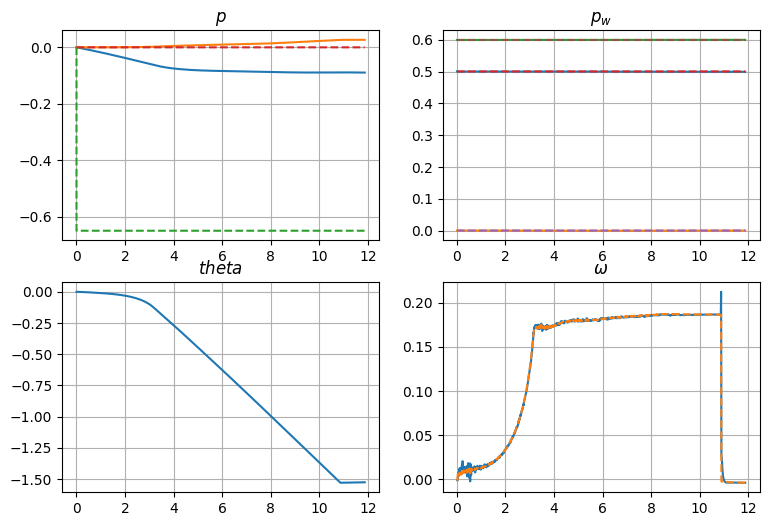

In [13]:

fig, ax = plt.subplots(2, 2, num=1, figsize=(9, 6))
ax[0, 0].plot(tt, pxt[:, :2])
ax[0, 0].plot(tt, prxt[:, :2], "--")
ax[0, 0].grid()
ax[0, 0].set_title("$p$")

ax[1, 0].plot(tt, ptht)
#ax[1, 0].plot(tt, rvt[:, :2], "--")
#ax[1, 0].plot(tt, ut[:, 0], ":")
ax[1, 0].grid()
ax[1, 0].set_title("$theta$")

ax[0, 1].plot(tt, xtw[:, :3])
ax[0, 1].plot(tt, rxtw[:, :3], "--")
ax[0, 1].grid()
ax[0, 1].set_title("$p_w$")

ax[1, 1].plot(tt, vt[:, 5])
ax[1, 1].plot(tt, rvt[:, 5], "--")
#ax[1, 1].plot(tt[:it], ut[:it, 1], ":")
ax[1, 1].grid()
ax[1, 1].set_title("$\\omega$")

plt.show()

# Coordinated motion


This example compares two cases for the same Cartesian goal. First, the arm tries to reach the target while the platform remains fixed. Then the same target is executed again while the base is allowed to move, increasing the reachable workspace of the mobile manipulator.


In [14]:
r.Restart()
r.ResetCurrentTarget()
b.ResetCurrentTarget()

First, restart the robot controller and reset the commanded targets of both subsystems. This gives a clean starting point before comparing the two reachability cases.


In [15]:
q_init = [0, -0.3, 0, -2.3,  0,  2.,  0.7776]
r._default.TaskDOF=np.array([1, 1, 1, 1, 1, 1])
r._default.DampedPseudoInverseFactor = 0.1
r._default.TaskContSpace = "World"
r._default.Traj="Trap"
b.CMoveToLocation([0, 0], rtheta=0)
r.JMove(q_init)
r.ResetCurrentTarget()

[RBS_DEBUG] [04:31:52.030] [tiagobase_PyMuJoCo]: CMoveToLocation -> CMoveToOri
[RBS_DEBUG] [04:31:52.030] [tiagobase_PyMuJoCo]: CMoveToOri started: theta=0.000
[RBS_DEBUG] [04:31:52.045] [tiagobase_PyMuJoCo]: CMoveToOri finished
[RBS_DEBUG] [04:31:52.045] [tiagobase_PyMuJoCo]: CMoveToLocation finished
[RBS_DEBUG] [04:31:52.045] [panda_PyMuJoCo]: JMove started: [ 0.0000 -0.3000  0.0000 -2.3000  0.0000  2.0000  0.7776] with velocity 25.0%
[RBS_DEBUG] [04:31:52.046] [panda_PyMuJoCo]: Execution time will be prolonged due to bounded joint velocities form 1.0s to 4.6s.
[RBS_DEBUG] [04:31:59.174] [panda_PyMuJoCo]: JMove finished


0

Next, set the controller defaults, move the platform to a known pose, and send the arm to the initial joint configuration. As in the robot tutorial, `TaskContSpace = "World"` means the Cartesian target is interpreted in the world frame.


In [16]:
x0 = r.x_ref
x1 = x0.copy()
x1[:3] += [1, -0.5, 0]
print("Initial robot pose:", x0)
print("Final   robot pose:", x1)


Initial robot pose: [ 0.5582 -0.0000  0.6671 -0.0001 -0.9999 -0.0087  0.0057]
Final   robot pose: [ 1.5582 -0.5000  0.6671 -0.0001 -0.9999 -0.0087  0.0057]


Here, `x0` is the current robot reference pose and `x1` is a displaced target pose. The translation `[1, -0.5, 0]` is chosen so the goal lies outside the arm-only workspace when the mobile base does not move.


## Arm-only attempt

In the first case, the platform remains fixed, so only the manipulator tries to execute the Cartesian motion. This demonstrates that a target can be valid in world coordinates but still unreachable for the arm when the base pose is unchanged.


In [17]:
r.ResetTime()
b.ResetTime()
ir = 0
ip = 0

r.StartCapture()
th_p = r.CMove(x1, 10, asynchronous=False)
r.StopCapture()

[RBS_DEBUG] [04:31:59.341] [panda_PyMuJoCo]: Capture started
[RBS_DEBUG] [04:31:59.343] [panda_PyMuJoCo]: CMove started: [ 1.5582 -0.5000  0.6671  0.0001  0.9999  0.0087 -0.0057] in World space in 10.0s
[RBS_WARN] [1779330737.422952175] [panda_PyMuJoCo]: No close solution found in 1001 iterations, err: [ 0.6796 -0.2326  0.1279  0.0410  0.1191 -0.0008]
[RBS_DEBUG] [04:32:17.423] [panda_PyMuJoCo]: CMove finished
[RBS_DEBUG] [04:32:17.423] [panda_PyMuJoCo]: Capture stopped


Reset time, clear the capture indices, start logging, and run `r.CMove(x1, 10)` without moving the platform. The capture callback stores both actual and commanded world-frame trajectories so the tracking error can be inspected afterward.


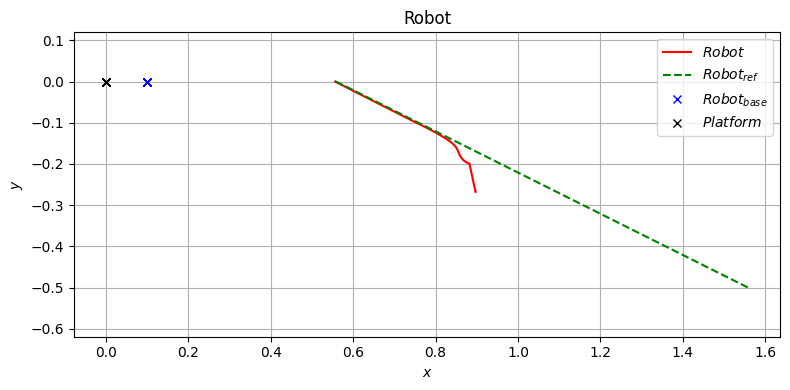

In [18]:
fig, ax = plt.subplots(1, 1, num=1, figsize=(8, 4))
ax = np.array(ax).flatten()
ax[0].plot(xtw[:,0],xtw[:,1], "r-", label="$Robot$")
ax[0].plot(rxtw[:,0],rxtw[:,1], "g--", label="$Robot_{ref}$")
ax[0].plot(rTbt[:,0],rTbt[:,1], "bx", label="$Robot_{base}$")
ax[0].plot(pxt[:,0],pxt[:,1], "kx", label="$Platform$")
ax[0].grid()
ax[0].axis("equal")
ax[0].set_xlabel("$x$")
ax[0].set_ylabel("$y$")
ax[0].set_title("Robot")
ax[0].legend()

plt.tight_layout()


The plot shows the actual end-effector path, the commanded reference path, the robot base pose, and the platform pose. Because the platform does not move, the end-effector trajectory stops short of the requested Cartesian target.


## Coordinated base-and-arm motion

Repeat the same Cartesian task, but allow the platform to move while the arm follows the target. The mobile base shifts the robot base frame so the final end-effector pose becomes reachable.


In [19]:
r.Restart()
r.ResetCurrentTarget()
b.ResetCurrentTarget()
b.CMoveToLocation([0, 0], rtheta=0)
r.JMove(q_init)
r.ResetCurrentTarget()

[RBS_DEBUG] [04:32:18.227] [tiagobase_PyMuJoCo]: CMoveToLocation -> CMoveToOri
[RBS_DEBUG] [04:32:18.227] [tiagobase_PyMuJoCo]: CMoveToOri started: theta=0.000
[RBS_DEBUG] [04:32:18.240] [tiagobase_PyMuJoCo]: CMoveToOri finished
[RBS_DEBUG] [04:32:18.240] [tiagobase_PyMuJoCo]: CMoveToLocation finished
[RBS_DEBUG] [04:32:18.240] [panda_PyMuJoCo]: JMove started: [ 0.0000 -0.3000  0.0000 -2.3000  0.0000  2.0000  0.7776] with velocity 25.0%
[RBS_DEBUG] [04:32:18.241] [panda_PyMuJoCo]: Execution time will be prolonged due to bounded joint velocities form 1.0s to 4.6s.
[RBS_DEBUG] [04:32:25.322] [panda_PyMuJoCo]: JMove finished


0

Before the coordinated run, restart the system, bring the platform to the nominal start pose, move the arm to `q_init`, and reset the current robot target. This ensures the second trial starts from the same configuration as the first one.


In [20]:
r.ResetTime()
b.ResetTime()
ir = 0
ip = 0

r.StartCapture()
th_b = b.CMoveToLocation([1.1, -0.6], rtheta=np.pi/4, asynchronous=True)
th_p = r.CMove(x1, 10, asynchronous=False)
while th_b.is_alive():
     r.Update()
r.StopCapture()

[RBS_DEBUG] [04:32:25.468] [panda_PyMuJoCo]: Capture started
[RBS_DEBUG] [04:32:25.470] [tiagobase_PyMuJoCo]: ASYNC CMoveToLocation
[RBS_DEBUG] [04:32:25.470] [panda_PyMuJoCo]: CMove started: [ 1.5582 -0.5000  0.6671  0.0001  0.9999  0.0087 -0.0057] in World space in 10.0s
[RBS_DEBUG] [04:32:39.881] [tiagobase_PyMuJoCo]: CMoveToLocation -> CMoveToOri
[RBS_DEBUG] [04:32:39.883] [tiagobase_PyMuJoCo]: CMoveToOri started: theta=0.785
[RBS_DEBUG] [04:32:40.002] [tiagobase_PyMuJoCo]: CMoveToOri finished
[RBS_DEBUG] [04:32:40.003] [tiagobase_PyMuJoCo]: CMoveToLocation finished
[RBS_DEBUG] [04:32:43.102] [panda_PyMuJoCo]: CMove finished
[RBS_DEBUG] [04:32:43.102] [panda_PyMuJoCo]: Capture stopped


During the coordinated run, the platform command is launched asynchronously with `b.CMoveToLocation(...)`, while the robot executes `r.CMove(x1, 10)` in the world frame. The `while th_b.is_alive(): r.Update()` loop keeps robot states and the capture callback updated until the platform thread finishes.


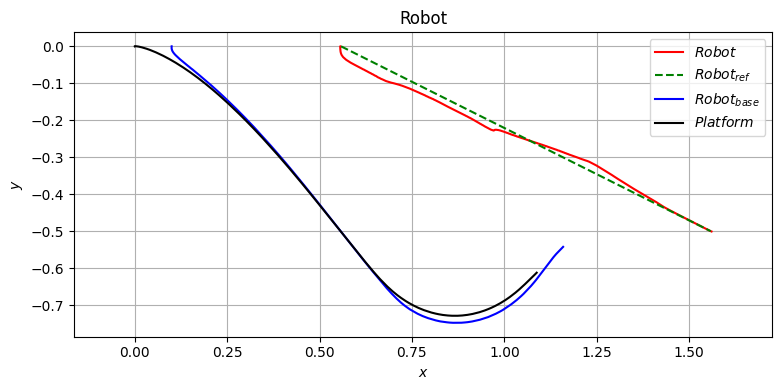

In [21]:
fig, ax = plt.subplots(1, 1, num=1, figsize=(8, 4))
ax = np.array(ax).flatten()
ax[0].plot(xtw[:,0],xtw[:,1], "r-", label="$Robot$")
ax[0].plot(rxtw[:,0],rxtw[:,1], "g--", label="$Robot_{ref}$")
ax[0].plot(rTbt[:,0],rTbt[:,1], "b-", label="$Robot_{base}$")
ax[0].plot(pxt[:,0],pxt[:,1], "k-", label="$Platform$")
ax[0].grid()
ax[0].axis("equal")
ax[0].set_xlabel("$x$")
ax[0].set_ylabel("$y$")
ax[0].set_title("Robot")
ax[0].legend()

plt.tight_layout()


Comparing this plot with the previous one shows the benefit of the mobile-manipulator formulation: the platform trajectory changes the robot-base path, and the arm can now follow the world-frame reference much more closely.


# Autonomous platform motion


This example uses the autonomous vector-field controller. Unlike the previous examples, the platform is no longer commanded toward a single target pose. Instead, it continuously generates local linear and angular velocity commands from the current manipulator configuration.


In [22]:
r.Restart()
r.ResetCurrentTarget()
b.ResetCurrentTarget()
b.CMoveToLocation([0, 0], rtheta=0)
r.JMove(q_init)
r.ResetCurrentTarget()

[RBS_DEBUG] [04:32:43.827] [tiagobase_PyMuJoCo]: CMoveToLocation -> CMoveToOri
[RBS_DEBUG] [04:32:43.827] [tiagobase_PyMuJoCo]: CMoveToOri started: theta=0.000
[RBS_DEBUG] [04:32:43.842] [tiagobase_PyMuJoCo]: CMoveToOri finished
[RBS_DEBUG] [04:32:43.842] [tiagobase_PyMuJoCo]: CMoveToLocation finished
[RBS_DEBUG] [04:32:43.842] [panda_PyMuJoCo]: JMove started: [ 0.0000 -0.3000  0.0000 -2.3000  0.0000  2.0000  0.7776] with velocity 25.0%
[RBS_DEBUG] [04:32:43.843] [panda_PyMuJoCo]: Execution time will be prolonged due to bounded joint velocities form 1.0s to 4.6s.
[RBS_DEBUG] [04:32:50.938] [panda_PyMuJoCo]: JMove finished


0

As before, restart the system, bring the platform to a known planar pose, move the Panda arm to `q_init`, and reset the robot target. This gives the autonomous base controller a clean initial configuration before the end-effector starts moving toward `x1`.


In [23]:
from robotblockset.platform_utils import track_panda_vf
r.ResetTime()
b.ResetTime()
ir = 0
ip = 0

r.StartCapture()
b.AutonomousMotion(callback=track_panda_vf, platform=b, a_max=0.25, alpha=0.25, f_zone=0.12, b_zone=0.1)
r.CMove(x1, 10)
r.CMove(x1, 2)
b.AbortAutonomousMotion()
r.StopCapture()


[RBS_DEBUG] [04:32:51.090] [panda_PyMuJoCo]: Capture started
[RBS_DEBUG] [04:32:51.091] [tiagobase_PyMuJoCo]: ASYNC AutonmousMotion
[RBS_DEBUG] [04:32:51.092] [tiagobase_PyMuJoCo]: AutonmousMotion started
[RBS_DEBUG] [04:32:51.093] [panda_PyMuJoCo]: CMove started: [ 1.5582 -0.5000  0.6671  0.0001  0.9999  0.0087 -0.0057] in World space in 10.0s
[RBS_DEBUG] [04:33:08.840] [panda_PyMuJoCo]: CMove finished
[RBS_DEBUG] [04:33:08.840] [panda_PyMuJoCo]: CMove started: [ 1.5582 -0.5000  0.6671  0.0001  0.9999  0.0087 -0.0057] in World space in 2.0s
[RBS_DEBUG] [04:33:12.843] [panda_PyMuJoCo]: CMove finished
[RBS_DEBUG] [04:33:12.844] [panda_PyMuJoCo]: Capture stopped


## Local vector-field controller

`track_panda_vf` runs as the callback for `b.AutonomousMotion(...)`. The controller uses a reduced 5-DoF Panda kinematic model and only the translational TCP position relative to the robot base, so the base behavior is local and does not depend on global localization.

The logic follows the zone-based description from `auto_platform.tex`:

- when the TCP is comfortably inside the workspace, the platform holds position,
- when the TCP approaches the outer workspace boundary, the platform drives forward,
- when the TCP gets too close to the base, the platform enters retreat mode and moves backward while reorienting.

The arguments in this example define the main autonomous-motion parameters: `a_max` limits linear acceleration, `alpha` sets exponential smoothing of the commanded velocities, `f_zone` is the forward-activation threshold near the outer reach boundary, and `b_zone` is the retreat threshold near the inner safety zone.

The autonomous controller is started first, then the robot performs two `CMove` commands toward the same Cartesian goal. During these motions, the platform thread keeps updating `Set_vel([v, omega])` from the current TCP position. Finally, `b.AbortAutonomousMotion()` stops the autonomous thread and `r.StopCapture()` ends logging.


[RBS_DEBUG] [04:33:12.862] [tiagobase_PyMuJoCo]: AutonmousMotion finished


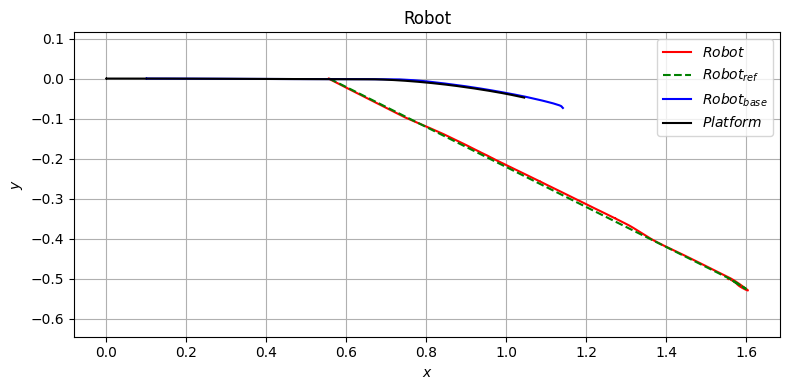

In [24]:
fig, ax = plt.subplots(1, 1, num=1, figsize=(8, 4))
ax = np.array(ax).flatten()
ax[0].plot(xtw[:,0],xtw[:,1], "r-", label="$Robot$")
ax[0].plot(rxtw[:,0],rxtw[:,1], "g--", label="$Robot_{ref}$")
ax[0].plot(rTbt[:,0],rTbt[:,1], "b-", label="$Robot_{base}$")
ax[0].plot(pxt[:,0],pxt[:,1], "k-", label="$Platform$")
ax[0].grid()
ax[0].axis("equal")
ax[0].set_xlabel("$x$")
ax[0].set_ylabel("$y$")
ax[0].set_title("Robot")
ax[0].legend()

plt.tight_layout()


Compare the resulting plot with the previous coordinated-motion examples. Here, the platform trajectory is generated by the reactive velocity field rather than by a single planned base goal. The curves show how the autonomous controller keeps the robot base in a favorable workspace region while the arm tracks the Cartesian command.
